## **Model training with the torch.nn module**

yes it provide a bunch of options so pretty good to use then the custom made 

In [1]:
import torch
import numpy as np
import torch.nn as nn


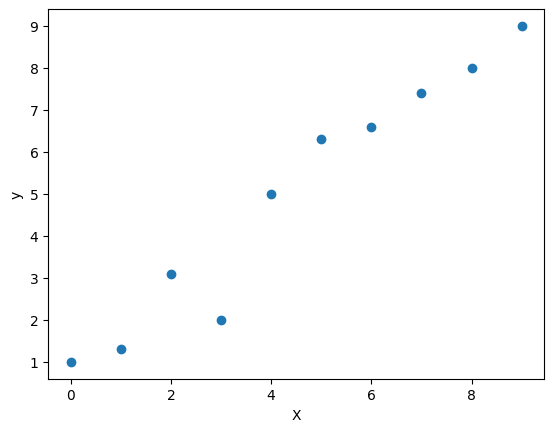

In [6]:
# creating the random data
X_train = np.arange(10 , dtype = 'float32').reshape(10,1)
y_train = np.array([1.0 , 1.3 , 3.1 , 2.0 , 5.0 , 6.3 , 6.6 ,7.4 , 8.0, 9.0], dtype ='float32')

#plotting it on ..!
import matplotlib.pyplot as plt


plt.plot(X_train , y_train , 'o' , markersize = 6)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [7]:
# normalizing the Data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_train_norm = torch.from_numpy(X_train_norm)

y_train_norm = torch.from_numpy(y_train)


In [12]:
# creating the Dataset and dataloader 
from torch.utils.data import DataLoader , TensorDataset
from tqdm import tqdm 
train_ds = TensorDataset(X_train_norm , y_train_norm)



In [17]:
BATCH_SIZE = 1
train_dl = DataLoader(train_ds , BATCH_SIZE , shuffle = True)

for i in train_dl:
    print(i)
    

[tensor([[0.1741]]), tensor([6.3000])]
[tensor([[1.5667]]), tensor([9.])]
[tensor([[-1.5667]]), tensor([1.])]
[tensor([[0.5222]]), tensor([6.6000])]
[tensor([[-0.1741]]), tensor([5.])]
[tensor([[0.8704]]), tensor([7.4000])]
[tensor([[-0.5222]]), tensor([2.])]
[tensor([[-1.2185]]), tensor([1.3000])]
[tensor([[-0.8704]]), tensor([3.1000])]
[tensor([[1.2185]]), tensor([8.])]


In [26]:
# traing the Model with torch.nn module

torch.manual_seed(42)

loss_fn = nn.MSELoss(reduction = 'mean')

input_size = 1
output_size = 1

model = nn.Linear(input_size , output_size)

optimizer = torch.optim.SGD(model.parameters() , lr = 0.001)


# starting the training loops
num_epochs = 200
log_epochs = 10
loss_val = []
for e in range(num_epochs):
    
    for x_batch , y_batch in train_dl:
        # generate _predctions
        pred = model(x_batch)[:,0]
        #calculating the loss
        loss = loss_fn(pred , y_batch)
        
        # compute gradients 
        loss.backward()
        
        #update the parameters using the gradients 
        optimizer.step()
        
        # reset the gradients to Zero 
        optimizer.zero_grad()
        
    if e % log_epochs == 0:
        loss_val.append(loss)
        print(f'Epoch {e} loss --> {loss.item():.3f}')

Epoch 0 loss --> 47.295
Epoch 10 loss --> 22.728
Epoch 20 loss --> 14.489
Epoch 30 loss --> 6.498
Epoch 40 loss --> 7.005
Epoch 50 loss --> 6.127
Epoch 60 loss --> 2.639
Epoch 70 loss --> 2.018
Epoch 80 loss --> 1.040
Epoch 90 loss --> 1.112
Epoch 100 loss --> 0.353
Epoch 110 loss --> 0.154
Epoch 120 loss --> 1.646
Epoch 130 loss --> 0.041
Epoch 140 loss --> 0.115
Epoch 150 loss --> 0.082
Epoch 160 loss --> 0.178
Epoch 170 loss --> 0.148
Epoch 180 loss --> 0.364
Epoch 190 loss --> 0.109


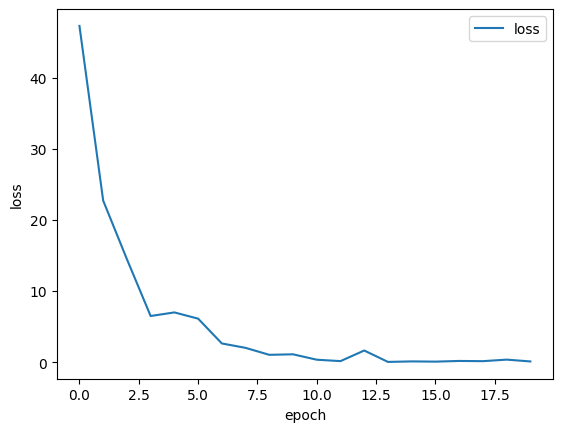

In [28]:
# plotting the loss curve
# Convert your loss to a numpy array as before
plt_loss = torch.tensor(loss_val).detach().numpy()

# Create an epoch array that matches the length of your loss values (0 to 19, or 1 to 20)
e = range(len(plt_loss))  # Or torch.arange(len(plt_loss))

# Plot the loss curve
plt.plot(e, plt_loss, label='loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [29]:
# final weights and the parameter 
print(f'Final parameters , weight {model.weight.item()}, bias {model.bias.item()}')

Final parameters , weight 2.6715855598449707, bias 4.8946685791015625
